In [3]:
import sys as _sys, os as _os
import warnings
import matplotlib as _mpl, matplotlib.font_manager as _fm

warnings.filterwarnings('ignore')

def _setup_korean_font():
    """Windows / macOS / Linux에서 한국어 폰트를 자동 감지해 matplotlib 기본 폰트로 설정."""
    _candidates = {
        'win32': [
            ('C:/Windows/Fonts/malgun.ttf',  'Malgun Gothic'),
            ('C:/Windows/Fonts/gulim.ttc',   'Gulim'),
            ('C:/Windows/Fonts/batang.ttc',  'Batang'),
        ],
        'darwin': [
            ('/System/Library/Fonts/AppleSDGothicNeo.ttc',               'Apple SD Gothic Neo'),
            ('/Library/Fonts/NanumGothic.ttf',                           'NanumGothic'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',          'NanumGothic'),
        ],
        'linux': [
            ('/usr/share/fonts-droid-fallback/truetype/DroidSansFallback.ttf', 'Droid Sans Fallback'),
            ('/usr/share/fonts/truetype/nanum/NanumGothic.ttf',                'NanumGothic'),
            ('/usr/share/fonts/truetype/droid/DroidSansFallback.ttf',          'Droid Sans Fallback'),
        ],
    }

    # 깨진 Full 변종 제거 (Linux 한정 이슈)
    _fm.fontManager.ttflist = [
        f for f in _fm.fontManager.ttflist
        if not (f.name == 'Droid Sans Fallback' and 'Full' in f.fname)
    ]

    platform = _sys.platform
    paths = _candidates.get(platform, _candidates['linux'])

    for path, name in paths:
        if _os.path.exists(path):
            _fm.fontManager.addfont(path)
            # 한글 폰트를 맨 앞에 두어 제목/축라벨 한글 깨짐 방지
            _mpl.rcParams['font.family'] = [name, 'DejaVu Sans']
            _mpl.rcParams['font.sans-serif'] = [
                name, 'Malgun Gothic', 'Apple SD Gothic Neo',
                'NanumGothic', 'Droid Sans Fallback', 'DejaVu Sans'
            ]
            print(f"[Font] Using Korean font: {name}")
            return name

    # 한국어 전용 폰트를 못 찾은 경우: 가능한 sans-serif fallback 목록 구성
    _mpl.rcParams['font.family'] = ['DejaVu Sans']
    _mpl.rcParams['font.sans-serif'] = [
        'Malgun Gothic', 'Apple SD Gothic Neo',
        'NanumGothic', 'Droid Sans Fallback', 'DejaVu Sans'
    ]
    print('[Font] Korean font not found explicitly. Using fallback sans-serif chain.')
    return None

_setup_korean_font()
_mpl.rcParams['axes.unicode_minus'] = False



[Font] Using Korean font: Malgun Gothic


# Partial Credit Model (PCM) — Bayesian Estimation with Stan

## 1. Model Description

The **Partial Credit Model** (Masters, 1982) is a polytomous generalisation of the Rasch model for items where partial credit is awarded (e.g., essay scores, problem-solving tasks with multiple steps).

### Category Probabilities

The **log-odds of category $k$ over category $k{-}1$** is defined as:

$$\log \frac{P(X_{ji} = k)}{P(X_{ji} = k-1)} = \theta_j - (\beta_i + \tau_{ik}), \quad k = 1, \ldots, K{-}1$$

with the constraint

$$
    \sum_{k} \tau_{ik} = 0
$$

Equivalently, the cumulative log-numerator for category $k$ is:

$$\ell_{ik} = \sum_{m=1}^{k}(\theta_j - \beta_i - \tau_{im}), \qquad \ell_{i0} \equiv 0$$

Then:

$$P(X_{ji} = k) = \frac{\exp(\ell_{ik})}{\sum_{c=0}^{K-1} \exp(\ell_{ic})}, \quad k = 0, 1, \ldots, K{-}1$$


| Parameter | Interpretation |
|-----------|----------------|
| $\theta_j$ | Person ability |
| $\beta_i$  | overall (average) item difficulty |
| $\tau_{ik}$ | Step difficulty: ability needed to prefer category $k$ over $k{-}1$ inside the item $i$|
| $\delta_{ik}$ | $\beta_i + \tau_{ik}$ |

### Key Properties
- **No discrimination parameter**: all items have slope = 1 (like the Rasch model).
- Step difficulties $\tau_{ik}$ are **not required to be ordered** — disordered thresholds are possible and indicate a category is rarely the most likely response.
- Reduces to the dichotomous Rasch model for $K = 2$.
- The PCM is essentially a chain of Rasch models, one per adjacent pair.

### Priors for Bayesian Inference
$$\theta_j \sim \mathcal{N}(0,1), \qquad \tau_{ik} \sim \mathcal{N}(0, 2)$$

$$ \sum_k \tau_{ik} = 0  $$

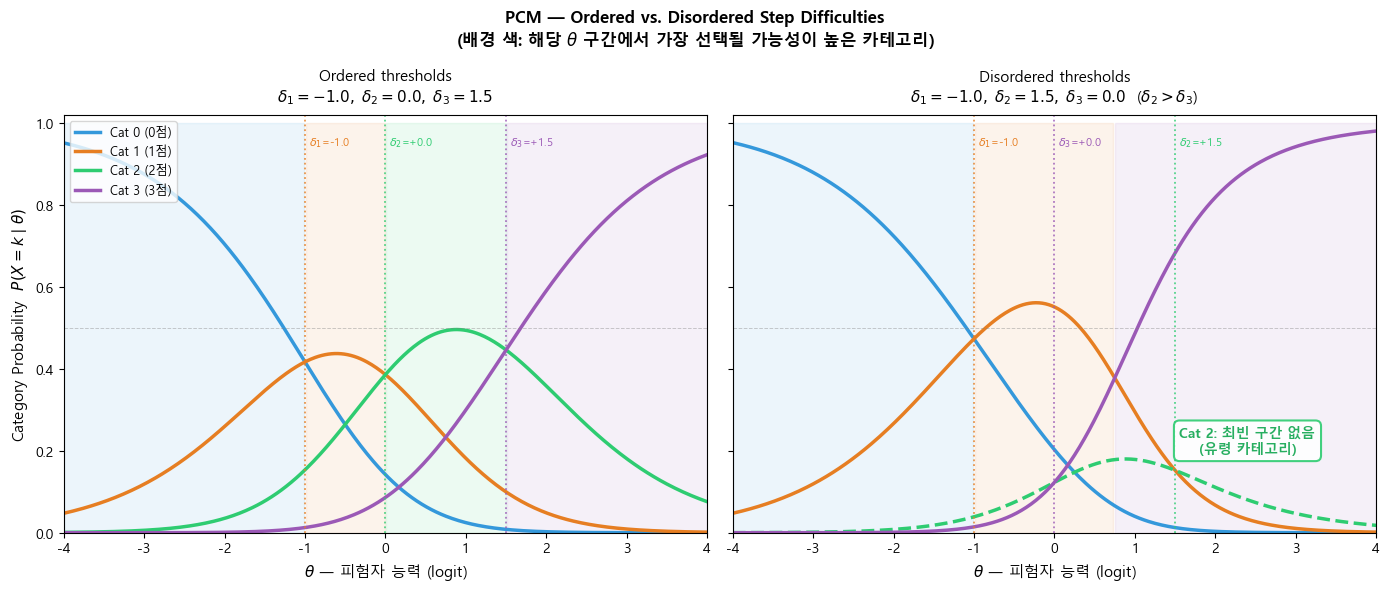

  능력 구간별 최빈(modal) 카테고리

[Ordered]  δ = [-1.   0.   1.5]
   θ ∈ (-4.00, -0.99)  →  Cat 0  (0점)
   θ ∈ (-0.99, +0.01)  →  Cat 1  (1점)
   θ ∈ (+0.01, +1.51)  →  Cat 2  (2점)
   θ ∈ (+1.51, +4.00)  →  Cat 3  (3점)

[Disordered]  δ = [-1.   1.5  0. ]
   θ ∈ (-4.00, -0.99)  →  Cat 0  (0점)
   θ ∈ (-0.99, +0.75)  →  Cat 1  (1점)
   θ ∈ (+0.75, +4.00)  →  Cat 3  (3점)


In [4]:
import numpy as np
import matplotlib.pyplot as plt

# ── PCM 확률 함수 (자립형: 이 셀 단독 실행 가능) ──────────────────────────
def pcm_probs_demo(theta, delta):
    """PCM category probabilities. delta: array of K-1 step difficulties."""
    K = len(delta) + 1
    log_num = np.zeros(K)
    cumsum = 0.0
    for k in range(1, K):
        cumsum += theta - delta[k - 1]
        log_num[k] = cumsum
    log_num -= log_num.max()          # 수치 안정화
    probs = np.exp(log_num)
    return probs / probs.sum()

# ── 두 가지 δ 시나리오 ─────────────────────────────────────────────────────
delta_ordered    = np.array([-1.0,  0.0,  1.5])   # ordered case
delta_disordered = np.array([-1.0,  1.5,  0.0])   # disordered case: δ2 > δ3

beta_ordered = delta_ordered.mean()
tau_ordered = delta_ordered - beta_ordered

beta_disordered = delta_disordered.mean()
tau_disordered = delta_disordered - beta_disordered

theta_range = np.linspace(-4, 4, 400)
cat_colors  = ['#3498DB', '#E67E22', '#2ECC71', '#9B59B6']
cat_labels  = ['Cat 0 (0점)', 'Cat 1 (1점)', 'Cat 2 (2점)', 'Cat 3 (3점)']

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, delta, title, is_ordered in zip(
        axes,
        [delta_ordered, delta_disordered],
        ['Ordered thresholds\n'
         r'$\delta_1 = -1.0,\;\delta_2 = 0.0,\;\delta_3 = 1.5$',
         'Disordered thresholds\n'
         r'$\delta_1 = -1.0,\;\delta_2 = 1.5,\;\delta_3 = 0.0$  ($\delta_2 > \delta_3$)'],
        [True, False]):

    # 카테고리별 확률 곡선 계산
    probs_matrix = np.array(
        [[pcm_probs_demo(t, delta)[k] for t in theta_range] for k in range(4)]
    )  # shape: (K, len(theta_range))

    # 배경: 최빈(modal) 카테고리 구간 색상 표시
    modal = probs_matrix.argmax(axis=0)
    for k in range(4):
        mask = (modal == k)
        if mask.any():
            ax.fill_between(theta_range, 0, 1, where=mask,
                            alpha=0.09, color=cat_colors[k])

    # 확률 곡선
    for k in range(4):
        ls = '-' if (is_ordered or k != 2) else '--'
        ax.plot(theta_range, probs_matrix[k],
                color=cat_colors[k], linewidth=2.5, linestyle=ls,
                label=cat_labels[k])

    # δ 수직선 표시
    for k, dv in enumerate(delta):
        ax.axvline(dv, color=cat_colors[k + 1], linestyle=':', linewidth=1.3, alpha=0.8)
        ax.text(dv + 0.05, 0.97, f'$\\delta_{k+1}$={dv:+.1f}',
                ha='left', va='top', fontsize=8, color=cat_colors[k + 1])

    # Disordered 경우: Cat 2가 최빈 구간 없음을 명시
    if not is_ordered:
        ax.text(.80, 0.22, 'Cat 2: 최빈 구간 없음\n(유령 카테고리)',
                transform=ax.transAxes, ha='center', va='center',
                fontsize=10, color='#27AE60', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='#2ECC71', linewidth=1.5, alpha=0.9))

    ax.set_xlim(-4, 4); ax.set_ylim(0, 1.02)
    ax.set_xlabel('$\\theta$ — 피험자 능력 (logit)', fontsize=11)
    ax.set_title(title, fontsize=11, pad=10)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.7, alpha=0.4)

axes[0].set_ylabel('Category Probability  $P(X = k \\mid \\theta)$', fontsize=11)
axes[0].legend(fontsize=9, loc='upper left')

fig.suptitle('PCM — Ordered vs. Disordered Step Difficulties\n'
             '(배경 색: 해당 $\\theta$ 구간에서 가장 선택될 가능성이 높은 카테고리)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ── 능력 구간별 최빈 카테고리 텍스트 출력 ──────────────────────────────────
print("=" * 55)
print("  능력 구간별 최빈(modal) 카테고리")
print("=" * 55)
for delta, label in [(delta_ordered, "Ordered"), (delta_disordered, "Disordered")]:
    print(f"\n[{label}]  δ = {delta}")
    modal_arr = np.array([pcm_probs_demo(t, delta) for t in theta_range]).argmax(axis=1)
    prev_k, start_t = modal_arr[0], theta_range[0]
    for idx in range(1, len(theta_range)):
        t, k = theta_range[idx], modal_arr[idx]
        if k != prev_k:
            print(f"   θ ∈ ({start_t:+.2f}, {t:+.2f})  →  Cat {prev_k}  ({prev_k}점)")
            prev_k, start_t = k, t
    print(f"   θ ∈ ({start_t:+.2f}, {theta_range[-1]:+.2f})  →  Cat {prev_k}  ({prev_k}점)")


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import os, tempfile, warnings
import cmdstanpy

warnings.filterwarnings('ignore')
np.random.seed(5101)

# # 3번 셀을 건너뛰고 실행해도 한글 폰트가 우선 적용되도록 보강
# mpl.rcParams['axes.unicode_minus'] = False
# if isinstance(mpl.rcParams.get('font.family', []), str):
#     current_family = [mpl.rcParams['font.family']]
# else:
#     current_family = list(mpl.rcParams.get('font.family', []))

# preferred = ['Malgun Gothic', 'Apple SD Gothic Neo', 'NanumGothic', 'Droid Sans Fallback']
# for f in preferred:
#     if f not in current_family:
#         current_family.insert(0, f)
# mpl.rcParams['font.family'] = current_family

## 2. Synthetic Data Generation

- 77 students, 20 items, **4 categories** (0–3). Step difficulties are drawn freely (no ordering required).
- 학생 수를 증가시키면 아이템 파라메터의 정확도가 높아진다. 실험으로 확인하시오.

In [34]:
J, I, K = 177, 20, 4

theta_true = np.random.normal(0, 1, J)
# delta shape: (I, K-1) — step difficulties, free ordering
delta_true = np.random.normal(0, 1.2, (I, K - 1))

delta_true[0] = [-1.0, 0.0, 1.5]  # ordered case
#

beta_true = delta_true.mean(axis=1)
tau_true = delta_true - beta_true[:, None]


def pcm_probs(theta, beta, tau):
    """PCM category probabilities for one person-item pair."""
    log_num = np.zeros(K)
    cumsum = 0.0
    for k in range(1, K):
        cumsum += theta - (beta + tau[k - 1])
        log_num[k] = cumsum
    log_num -= log_num.max()   # numerical stability
    probs = np.exp(log_num)
    return probs / probs.sum()

Y = np.zeros((J, I), dtype=int)
for j in range(J):
    for i in range(I):
        pr = pcm_probs(theta_true[j], beta_true[i], tau_true[i])  # using decomposed parameters
        Y[j, i] = np.random.choice(K, p=pr)

print(f"Response shape: {Y.shape},  Categories: {np.unique(Y)}")
print(f"Category counts: {np.bincount(Y.ravel())}")

Response shape: (177, 20),  Categories: [0 1 2 3]
Category counts: [1337  703  680  820]


In [35]:
# the code is 0-based, so categories are 0, 1, 2, 3
Y

array([[0, 0, 0, ..., 3, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [0, 2, 0, ..., 3, 0, 2],
       ...,
       [3, 3, 3, ..., 3, 3, 3],
       [3, 3, 0, ..., 2, 3, 2],
       [3, 2, 1, ..., 0, 0, 1]])

## 3. Stan Model Code

In [36]:
stan_code = """
data {
  int<lower=1> J;              // Number of persons
  int<lower=1> I;              // Number of items
  int<lower=2> K;              // Number of categories (e.g., 4 for 0, 1, 2, 3)
  int<lower=0> N;              // Total number of observations
  array[N] int<lower=1,upper=J> jj; // Person index for each observation
  array[N] int<lower=1,upper=I> ii; // Item index for each observation
  array[N] int<lower=1,upper=K> y;  // Response data (must be 1 to K)
}

parameters {
  vector[J] theta;             // Latent ability for each person
  real<lower=0> sigma_theta;   // Standard deviation of abilities
  
  vector[I-1] beta_free;       // Item difficulty (I-1 free parameters for identification)
  matrix[I, K-2] tau_free;     // Step difficulty (K-2 free parameters per item)
}

transformed parameters {
  vector[I] beta;              // Full item difficulty vector
  matrix[I, K-1] tau;          // Full step difficulty matrix (K-1 thresholds)

  // 1. Identification: Sum-to-zero constraint for beta
  // Fixes the mean of item difficulties to 0 to define the scale origin
  beta = append_row(beta_free, -sum(beta_free));

  // 2. Identification: Sum-to-zero constraint for tau per item
  // Ensures beta_i represents the average difficulty (center) of item i
  for (i in 1:I) {
    tau[i] = append_col(tau_free[i], -sum(tau_free[i]));
  }
}

model {
  // --- Priors ---
  // Person abilities follow a normal distribution centered at 0
  theta ~ normal(0, sigma_theta);      
  sigma_theta ~ exponential(1);
  
  // Weakly informative priors for item and step parameters
  beta_free ~ normal(0, 3);            
  to_vector(tau_free) ~ normal(0, 3);  

  // --- Likelihood (PCM Logic) ---
  for (n in 1:N) {
    vector[K] log_prob;
    real p_theta = theta[jj[n]];
    real i_beta = beta[ii[n]];
    
    // Basis for log-odds: first category is fixed to 0
    log_prob[1] = 0; 
    
    // Accumulate log-odds for adjacent categories
    // log(P_k / P_{k-1}) = theta - (beta + tau_{k-1})
    for (k in 2:K) {
      log_prob[k] = log_prob[k-1] + (p_theta - (i_beta + tau[ii[n], k-1]));
    }
    
    // Standard categorical_logit performs softmax internally
    y[n] ~ categorical_logit(log_prob);
  }
}

generated quantities {
  // Can be used for calculating Posterior Predictive Checks (PPC) or Fit Statistics
}
"""

In the Stan code provided, identifiability is obtained through a **two-level hierarchical anchoring system**. 

Without these constraints, the model would suffer from "location shift" (you could add 5 to all abilities and 5 to all difficulties without changing the likelihood) and "parameter collinearity" (the model wouldn't know where the item ends and the steps begin).

Here is exactly how the code solves this:

### 1. Global Identification: Fixing the Scale Origin
The most critical issue in IRT is defining where "zero" is on the latent continuum. The code achieves this by anchoring the **Item Difficulties ($\beta$)**.

* **The Mechanism**: 
    ```stan
    beta = append_row(beta_free, -sum(beta_free));
    ```
* **The Logic**: By defining `beta_free` with $I-1$ elements and calculating the last element as the negative sum of the others, the code mathematically forces $\sum_{i=1}^I \beta_i = 0$.
* **The Result**: This sets the "zero point" of your logit scale at the **average difficulty of your item pool**. Consequently, a person with $\theta = 0$ is someone whose ability perfectly matches the average difficulty of all items in the test.

---

### 2. Local Identification: Separating Item Mean from Steps
In a decomposed PCM, an item has a "general difficulty" ($\beta_i$) and "specific step deviations" ($\tau_{ik}$). Without a constraint, these two are perfectly collinear—you could increase $\beta_i$ and decrease all $\tau_{ik}$ by the same amount, and the probability would remain identical.

* **The Mechanism**: 
    ```stan
    tau[i] = append_col(tau_free[i], -sum(tau_free[i]));
    ```
* **The Logic**: For every single item $i$, the sum of its step parameters is forced to zero ($\sum_{k=1}^{K-1} \tau_{ik} = 0$).
* **The Result**: This uniquely identifies $\beta_i$ as the **mean location** (the "center of gravity") of that item's thresholds. It ensures that $\tau$ purely represents the *spacing* between categories, while $\beta$ represents the *location* of the item.

---

### 3. Distributional Identification: The Person Side
You might notice that the person abilities also have a prior: 
```stan
theta ~ normal(0, sigma_theta);
```
While this is a "soft" constraint compared to the sum-to-zero logic used for items, it helps stabilize the model. Because the items are already anchored at 0 (Global Identification), the model can now freely estimate the **mean and variance ($\sigma_\theta$)** of the person population relative to those items. 

If you had *not* anchored the items via `sum-to-zero`, you would have had to anchor the persons by fixing `theta ~ normal(0, 1)` (fixing both mean and variance).

---

### Summary Table of Constraints

| Level | Parameter | Constraint Type | Purpose |
| :--- | :--- | :--- | :--- |
| **Global** | $\beta$ | $\sum \beta_i = 0$ | Defines the "0" point on the ruler (test-centered). |
| **Local** | $\tau$ | $\sum_{k} \tau_{ik} = 0$ | Distinguishes item difficulty from category spacing. |
| **Scale** | Discrimination | Implicitly fixed to $1.0$ | Standard Rasch assumption; fixes the unit of the logit. |

### Why this is better than "Pinning"
Instead of "pinning" one item to zero (e.g., $\beta_1 = 0$), which is another common way to identify models, the **sum-to-zero** approach is generally preferred in Bayesian research because:
1.  It doesn't make the entire scale dependent on the measurement error of a single "reference item."
2.  It makes the interpretation of $\beta$ much more intuitive as the "average difficulty."

Since you are moving toward a **Double Explanatory Model**, this setup is ideal. It allows your item covariates ($X$) to explain deviations from the average difficulty without the model "drifting" in latent space.


In [37]:
# prepare data for Stan: convert from 2D (J, I) to long format (N = J*I)
# Notice: Wide-form data may be directly used. However, for demonstration, we convert to long format.
# Stan은 1-based indexing이므로 각 인덱스에 +1을 해줍니다.

jj_arr, ii_arr, y_arr = [], [], []
for j in range(J):
    for i in range(I):
        jj_arr.append(j + 1)  # Stan은 1-based indexing이므로 +1 
        ii_arr.append(i + 1)  # Stan은 1-based indexing이므로 +1
        y_arr.append(int(Y[j, i]) + 1) # Stan은 1-based indexing이므로 +1

stan_data = {'J': J, 'I': I, 'K': K, 'N': J * I,
             'jj': jj_arr, 'ii': ii_arr, 'y': y_arr}


### Compile the Stan Code


In [38]:
tmpdir = tempfile.mkdtemp()
stan_path = os.path.join(tmpdir, 'pcm.stan')
with open(stan_path, 'w') as f:
    f.write(stan_code)

model = cmdstanpy.CmdStanModel(stan_file=stan_path)
print('Compiled.')

23:06:06 - cmdstanpy - INFO - compiling stan file C:\Users\yongd\AppData\Local\Temp\tmpb2jzusoi\pcm.stan to exe file C:\Users\yongd\AppData\Local\Temp\tmpb2jzusoi\pcm.exe


23:06:18 - cmdstanpy - INFO - compiled model executable: C:\Users\yongd\AppData\Local\Temp\tmpb2jzusoi\pcm.exe


Compiled.


## 4a. MAP Estimation

In [39]:
fit_map = model.optimize(
    data=stan_data, seed=5101,
)
theta_map = fit_map.stan_variable('theta')
beta_map = fit_map.stan_variable('beta')
tau_map = fit_map.stan_variable('tau')
delta_map = beta_map[:, None] + tau_map  # delta = beta + tau

print(f"MAP estimates for theta (first 5): {theta_map[:5]}")
print(f"MAP estimates for beta (first item): {beta_map[0]}")
print(f"MAP estimates for tau (first item): {tau_map[0]}")
print(f"MAP estimates for delta (first item): {delta_map[0]}")
print(f"True delta for first item: {delta_true[0]}")
print(f"MAP delta - True delta (first item): {delta_map[0] - delta_true[0]}")

23:06:18 - cmdstanpy - INFO - Chain [1] start processing


23:06:18 - cmdstanpy - INFO - Chain [1] done processing


MAP estimates for theta (first 5): [-0.95616273 -1.4670984   0.25931459 -0.02337114  0.35838748]
MAP estimates for beta (first item): -0.074884357
MAP estimates for tau (first item): [-0.82433567 -0.32250564  1.1468413 ]
MAP estimates for delta (first item): [-0.89922003 -0.39739     1.07195694]
True delta for first item: [-1.   0.   1.5]
MAP delta - True delta (first item): [ 0.10077997 -0.39739    -0.42804306]


## 4b. Bayesian Inference via MCMC

In [40]:
fit = model.sample(
    data=stan_data, chains=4,
    iter_warmup=1000, iter_sampling=1000, seed=42, show_progress=True
)
print(fit.diagnose())


23:06:22 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

23:07:16 - cmdstanpy - INFO - CmdStan done processing.
23:07:16 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'pcm.stan', line 38, column 2 to column 33)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in 'pcm.stan', line 38, column 2 to column 33)
Consider re-running with show_console=True if the above output is unclear!



Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



In [42]:
theta_est = fit.stan_variable('theta').mean(axis=0)
beta_est = fit.stan_variable('beta').mean(axis=0)
tau_est = fit.stan_variable('tau').mean(axis=0)
delta_est = beta_est[:, None] + tau_est  # delta = beta + tau

print(f"Theta corr: {np.corrcoef(theta_true, theta_est)[0,1]:.3f}")
print(f"\nStep difficulty recovery (first 5 items):")
print(f"{'Item':>5} {'d1_t':>7} {'d1_e':>7} {'d2_t':>7} {'d2_e':>7} {'d3_t':>7} {'d3_e':>7}")
for i in range(5):
    print(f"{i+1:>5} {delta_true[i,0]:>7.3f} {delta_est[i,0]:>7.3f} "
          f"{delta_true[i,1]:>7.3f} {delta_est[i,1]:>7.3f} "
          f"{delta_true[i,2]:>7.3f} {delta_est[i,2]:>7.3f}")


Theta corr: 0.963

Step difficulty recovery (first 5 items):
 Item    d1_t    d1_e    d2_t    d2_e    d3_t    d3_e
    1  -1.000  -1.026   0.000  -0.407   1.500   1.176
    2  -0.070  -0.577  -0.472  -0.516  -0.169  -0.237
    3  -1.064  -1.277   2.117   1.752  -0.371  -0.714
    4  -0.559  -0.593  -0.468  -1.320   1.700   1.568
    5   0.121   0.107   0.507  -0.390  -0.901  -1.107


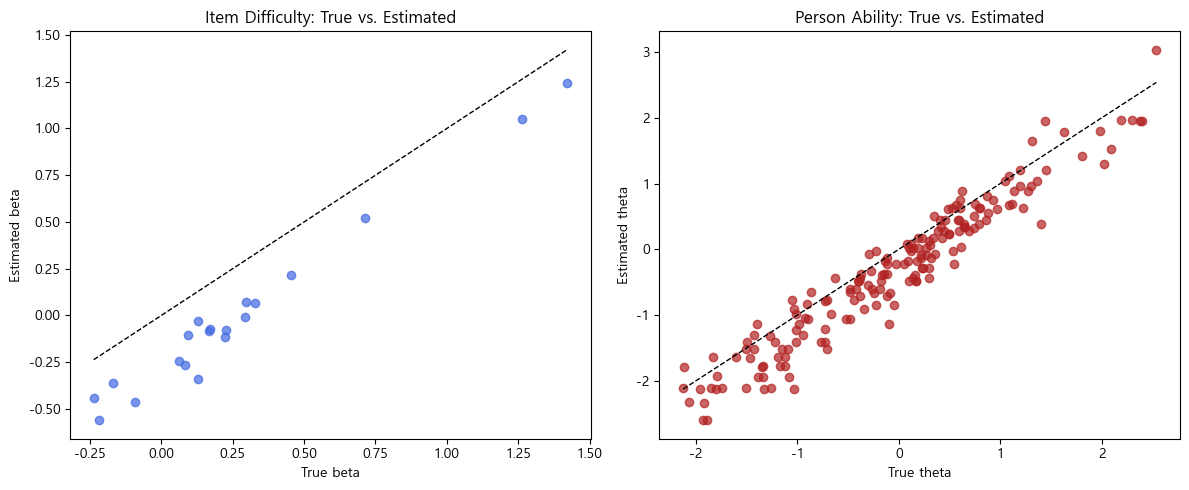

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# beta_true and beta_est are item difficulties (length I)
axes[0].scatter(beta_true, beta_est, color='royalblue', alpha=0.7)
axes[0].plot([beta_true.min(), beta_true.max()], [beta_true.min(), beta_true.max()], 'k--', lw=1)
axes[0].set_xlabel('True beta')
axes[0].set_ylabel('Estimated beta')
axes[0].set_title('Item Difficulty: True vs. Estimated')

# theta_true and theta_est are person abilities (length J)
axes[1].scatter(theta_true, theta_est, color='firebrick', alpha=0.7)
axes[1].plot([theta_true.min(), theta_true.max()], [theta_true.min(), theta_true.max()], 'k--', lw=1)
axes[1].set_xlabel('True theta')
axes[1].set_ylabel('Estimated theta')
axes[1].set_title('Person Ability: True vs. Estimated')

plt.tight_layout()
plt.show()

## 5. Visualizations

### 5a. Wright Map

In the PCM Wright map, each item's $K{-}1 = 3$ step difficulty parameters $\delta_{ik}$ are plotted on the logit scale. Unlike the GRM, step difficulties can be **disordered**: if $\delta_{i2} < \delta_{i1}$, category 1 is never the most probable response and corresponds to a "Guttman gap" in the scoring rubric.

**Interpretation**: Widely dispersed step difficulties indicate an item that spans a wide range of the ability scale. Clustered or disordered steps suggest the item's middle categories may be redundant — a sign to revise the scoring rubric.

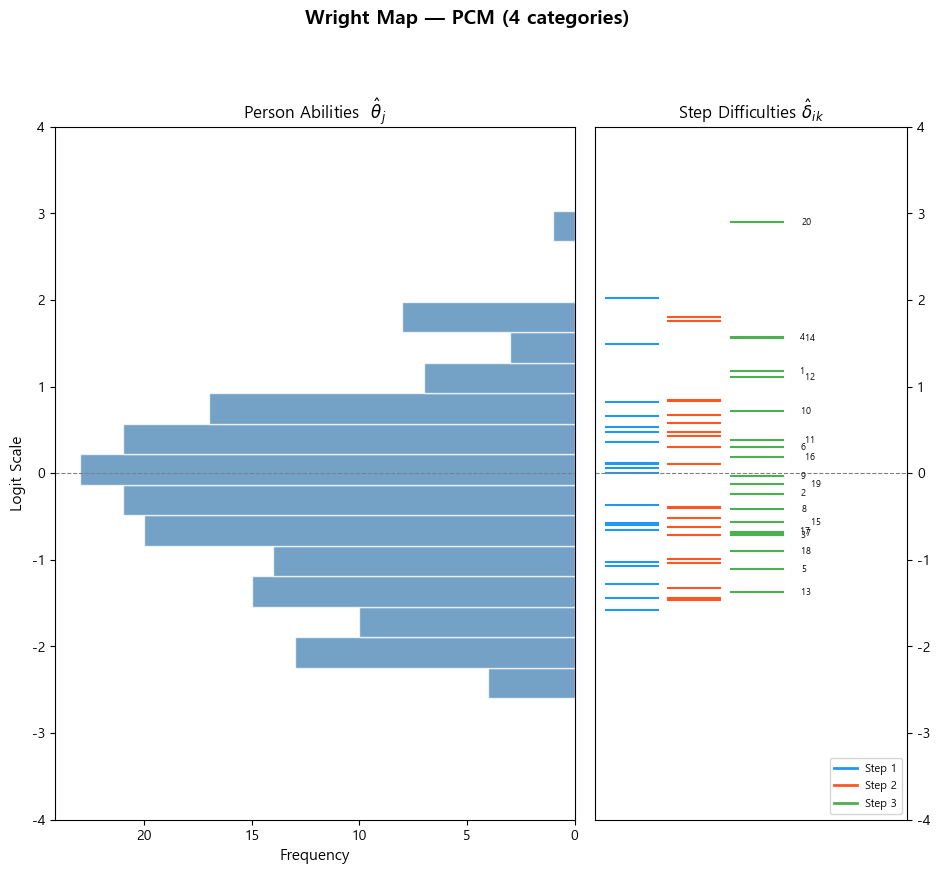

In [46]:
fig = plt.figure(figsize=(11, 9))
gs = gridspec.GridSpec(1, 2, width_ratios=[2.5, 1.5], wspace=0.05)
ax_p = fig.add_subplot(gs[0])
ax_i = fig.add_subplot(gs[1])
y_lim = (-4, 4)
step_colors = ['#2196F3', '#FF5722', '#4CAF50']

ax_p.hist(theta_est, bins=16, orientation='horizontal',
          color='steelblue', alpha=0.75, edgecolor='white')
ax_p.set_ylim(y_lim); ax_p.invert_xaxis()
ax_p.set_xlabel('Frequency', fontsize=11); ax_p.set_ylabel('Logit Scale', fontsize=11)
ax_p.set_title('Person Abilities  $\\hat{\\theta}_j$', fontsize=12)
ax_p.axhline(0, color='gray', linestyle='--', linewidth=0.8)

# Build offset map: detect items with similar step difficulties and spread them out
offset_map = {}
last_steps = delta_est[:, K - 2]

# Group items by proximity: if within 0.15 logits, assign to different x-positions
for i in range(I):
    dv_i = last_steps[i]
    # Count how many items have similar difficulty
    nearby = np.abs(last_steps - dv_i) < 0.15
    nearby_indices = np.where(nearby)[0]
    
    if len(nearby_indices) > 1:
        # Multiple items clustered; assign position based on rank within cluster
        rank = np.where(nearby_indices == i)[0][0]
        offset_map[i] = 0.035 + (rank % 3) * 0.025
    else:
        offset_map[i] = 0.04

for i in range(I):
    for k in range(K - 1):
        dv = delta_est[i, k]
        ax_i.plot([0.05 + k * 0.3, 0.3 + k * 0.3], [dv, dv],
                  color=step_colors[k], linewidth=1.5)
    dv_last = delta_est[i, K - 2]
    x_offset = offset_map.get(i, 0.04)
    ax_i.text(0.35 + (K - 2) * 0.3 + x_offset, dv_last, f'{i+1}', 
              fontsize=6.5, ha='left', va='center')
ax_i.set_ylim(y_lim); ax_i.set_xlim(0, 1.5); ax_i.set_xticks([])
ax_i.set_yticks(range(-4, 5)); ax_i.yaxis.set_label_position('right'); ax_i.yaxis.tick_right()
ax_i.set_title('Step Difficulties $\\hat{\\delta}_{ik}$', fontsize=12)
ax_i.axhline(0, color='gray', linestyle='--', linewidth=0.8)
for k in range(K - 1):
    ax_i.plot([], [], color=step_colors[k], linewidth=2, label=f'Step {k+1}')
ax_i.legend(loc='lower right', fontsize=8)

fig.suptitle('Wright Map — PCM (4 categories)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(tmpdir, 'wright_map_pcm.png'), dpi=120, bbox_inches='tight')
plt.show()

End.